# Student Data — Machine Learning Model Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Load Dataset

In [2]:
df = pd.read_csv("student_data-selected-columns.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob
0,GP,F,18,U,GT3,A,4,4,at_home,teacher
1,GP,F,17,U,GT3,T,1,1,at_home,other
2,GP,F,15,U,LE3,T,1,1,at_home,other
3,GP,F,15,U,GT3,T,4,2,health,services
4,GP,F,16,U,GT3,T,3,3,other,other


## Preprocessing

In [3]:
df_enc = df.copy()
le_dict = {}

cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    le_dict[col] = le

df_enc.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob
0,0,0,18,1,0,0,4,4,0,4
1,0,0,17,1,0,1,1,1,0,2
2,0,0,15,1,1,1,1,1,0,2
3,0,0,15,1,0,1,4,2,1,3
4,0,0,16,1,0,1,3,3,2,2


## Train-Test Split

In [4]:
X = df_enc.drop('sex', axis=1)
y = df_enc['sex']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

## Evaluation

In [6]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.531646,0.526061,0.531646,0.521883
1,Logistic Regression,0.506329,0.508739,0.506329,0.506804
2,Decision Tree,0.506329,0.505536,0.506329,0.505852
3,Random Forest,0.506329,0.505536,0.506329,0.505852
4,KNN,0.430380,0.431249,0.430380,0.430746
5,Naive Bayes,0.392405,0.395790,0.392405,0.391821


## Best Model

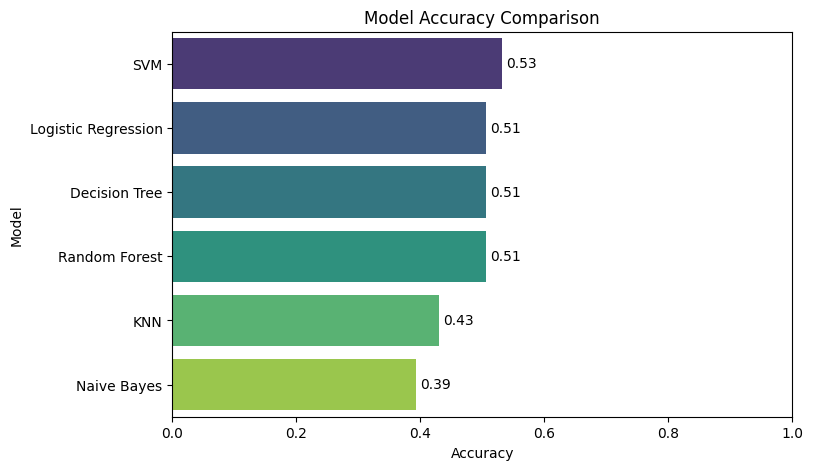

In [9]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.show()

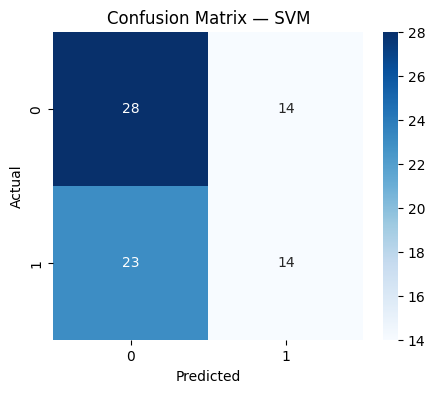

Best performing model: SVM


In [8]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Best performing model: {best_model_name}")

## Insights

- All models achieved accuracy in the 40-53% range, only marginally above
  random guessing — the dataset's gender split is roughly 53% female / 47%
  male, so even a "majority class" guess would score close to this.
- **SVM performed best** (about 53% accuracy), followed closely by Logistic
  Regression, Decision Tree, and Random Forest (about 50% each).
- **KNN and Naive Bayes underperformed**, likely because they're more
  sensitive to the categorical-to-numeric encoding used here.
- The key takeaway: family background features (parents' education, jobs,
  school, address, family size) have **very weak predictive power for a
  student's gender** — which makes sense, since gender isn't logically
  determined by these demographic factors. This is a useful negative
  result, not a failure of the models.

  